In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import timedelta

In [81]:
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (8, 5)

In [82]:
df = pd.read_excel("Sample - Superstore 2019.xls")
df.shape

(9994, 21)

In [83]:
df_raw = df.copy()
df_raw.shape

(9994, 21)

In [84]:
df_raw.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [85]:
print(df_raw.columns.tolist())
df_raw.info()

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Date       9994 non-null   datetime64[us]
 4   Ship Mode       9994 non-null   str           
 5   Customer ID     9994 non-null   str           
 6   Customer Name   9994 non-null   str           
 7   Segment         9994 non-null   str           
 8   Country/Region  9994 non-null   str           
 9   City            9994 non-null   str           
 10  State   

In [86]:
df_raw.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2016-110422,2016-01-21,2016-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180.0,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627.0,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627.0,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627.0,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2019-119914,2019-05-04,2019-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,California,92683.0,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [87]:
df_raw.isnull().sum()

Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

In [88]:
missing_postal = df_raw[df_raw["Postal Code"].isnull()]
print("Rows Missing Postal Code:", len(missing_postal))
missing_postal[["Order ID", "City", "State", "Postal Code"]]

Rows Missing Postal Code: 11


,Order ID,City,State,Postal Code
2234,CA-2019-104066,Burlington,Vermont,NaN
5274,CA-2017-162887,Burlington,Vermont,NaN
8798,US-2018-150140,Burlington,Vermont,NaN
9146,US-2018-165505,Burlington,Vermont,NaN
9147,US-2018-165505,Burlington,Vermont,NaN
9148,US-2018-165505,Burlington,Vermont,NaN
9386,US-2019-127292,Burlington,Vermont,NaN
9387,US-2019-127292,Burlington,Vermont,NaN
9388,US-2019-127292,Burlington,Vermont,NaN
9389,US-2019-127292,Burlington,Vermont,NaN


In [89]:
df_raw["Postal Code"] = df_raw["Postal Code"].fillna(5401)
df_raw.isnull().sum().sum()  # 0 = no missing values left anywhere

np.int64(0)

In [90]:
print("Fully Duplicated Rows:", df_raw.duplicated().sum())
print("Duplicated on (Order ID, Product ID):", df_raw.duplicated(subset=["Order ID", "Product ID"]).sum())

Fully Duplicated Rows: 0
Duplicated on (Order ID, Product ID): 8


In [91]:
string_cols = df_raw.select_dtypes("object").columns.tolist()

for col in string_cols:
    df_raw[col] = df_raw[col].str.strip().str.title()

for col in ["Ship Mode", "Segment", "Region", "Category"]:
    print(col, ":", sorted(df_raw[col].unique()))

Ship Mode : ['First Class', 'Same Day', 'Second Class', 'Standard Class']
Segment : ['Consumer', 'Corporate', 'Home Office']
Region : ['Central', 'East', 'South', 'West']
Category : ['Furniture', 'Office Supplies', 'Technology']


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23796\2607709372.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df_raw.select_dtypes("object").columns.tolist()


In [92]:
df_raw[["Order Date", "Ship Date"]] = df_raw[["Order Date", "Ship Date"]].apply(pd.to_datetime)
df_raw[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [93]:
cat_candidates = df_raw.select_dtypes("object").columns.tolist()
for col in cat_candidates:
    if df_raw[col].nunique() <= 50:
        df_raw[col] = df_raw[col].astype("category")

df_raw.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Date       9994 non-null   datetime64[us]
 4   Ship Mode       9994 non-null   category      
 5   Customer ID     9994 non-null   str           
 6   Customer Name   9994 non-null   str           
 7   Segment         9994 non-null   category      
 8   Country/Region  9994 non-null   category      
 9   City            9994 non-null   str           
 10  State           9994 non-null   category      
 11  Postal Code     9994 non-null   float64       
 12  Region          9994 non-null   category      
 13  Product ID      9994 non-null   str           
 14  Category        9994 non-null   category      
 15  Sub-Category   

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23796\1937197914.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_candidates = df_raw.select_dtypes("object").columns.tolist()


In [94]:
df_raw[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [95]:
print("Order Date Range:", df_raw["Order Date"].min().date(), "to", df_raw["Order Date"].max().date())
print("Unique Customers:", df_raw["Customer ID"].nunique())
print("Unique Orders: ", df_raw["Order ID"].nunique())
print("Order Lines: ", len(df_raw))

Order Date Range: 2016-01-03 to 2019-12-30
Unique Customers: 793
Unique Orders:  5009
Order Lines:  9994


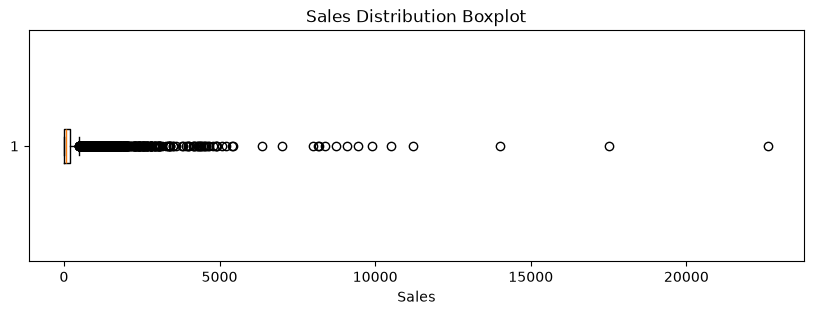

Sales outlier bounds: [-271.71, 498.93]
Number of Sales line-item outliers: 1167 (11.7% of rows)


In [96]:
# Visual check for outliers in Sales using a boxplot
plt.figure(figsize=(10, 3))
plt.boxplot(df_raw["Sales"], orientation="horizontal")
plt.title("Sales Distribution Boxplot")
plt.xlabel("Sales")
plt.show()

# IQR method: flag numeric outliers beyond 1.5x the interquartile range
q1, q3 = df_raw["Sales"].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df_raw[(df_raw["Sales"] < lower_bound) | (df_raw["Sales"] > upper_bound)]
print(f"Sales outlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print("Number of Sales line-item outliers:", len(outliers), f"({len(outliers)/len(df_raw):.1%} of rows)")

In [97]:
# Snapshot date = the day after the most recent order in the dataset
snapshot_date = df_raw["Order Date"].max() + timedelta(days=1)
print("Snapshot date used for Recency:", snapshot_date.date())

Snapshot date used for Recency: 2019-12-31


In [98]:
rfm = (
    df_raw.groupby(["Customer ID", "Customer Name"])
    .agg(
        Recency=("Order Date", lambda dates: (snapshot_date - dates.max()).days),
        Frequency=("Order ID", "nunique"),
        Monetary=("Sales", "sum"),
    )
    .reset_index()
)

print("Customers in RFM Table:", len(rfm))
rfm.head()

Customers in RFM Table: 793


,Customer ID,Customer Name,Recency,Frequency,Monetary
0,Aa-10315,Alex Avila,185,5,5563.560
1,Aa-10375,Allen Armold,20,9,1056.390
2,Aa-10480,Andrew Allen,260,4,1790.512
3,Aa-10645,Anna Andreadi,56,6,5086.935
4,Ab-10015,Aaron Bergman,416,3,886.156


In [99]:
# Check: one row per unique customer, no negatives, Monetary matches total Sales
assert rfm["Customer ID"].is_unique
assert (rfm["Recency"] >= 0).all()
assert (rfm["Frequency"] >= 1).all()
print("Total Monetary across all customers: ${:,.2f}".format(rfm["Monetary"].sum()))
print("Total Sales in cleaned data: ${:,.2f}".format(df_raw["Sales"].sum()))

rfm[["Recency", "Frequency", "Monetary"]].describe()

Total Monetary across all customers: $2,297,200.86
Total Sales in cleaned data: $2,297,200.86


,Recency,Frequency,Monetary
count,793.000000,793.000000,793.000000
mean,147.769231,6.316520,2896.848500
std,186.091317,2.550885,2628.670117
min,1.000000,1.000000,4.833000
25%,31.000000,5.000000,1146.050000
50%,76.000000,6.000000,2256.394000
75%,184.000000,8.000000,3785.276000
max,1165.000000,17.000000,25043.050000


In [100]:
# 1) Rank: qcut so ties don't break equal-sized quintile binning
rfm["R_Score"] = pd.qcut(rfm["Recency"].rank(method="first"), q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# 2) Combine into a single RFM score/code
rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]
rfm["RFM_Segment_Code"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str)

rfm[["Customer Name", "Recency", "Frequency", "Monetary", "R_Score", "F_Score", "M_Score", "RFM_Score", "RFM_Segment_Code"]].head(10)

,Customer Name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment_Code
0,Alex Avila,185,5,5563.560,2,2,5,9,22
1,Allen Armold,20,9,1056.390,5,5,2,12,55
2,Andrew Allen,260,4,1790.512,1,1,3,5,11
3,Anna Andreadi,56,6,5086.935,3,3,5,11,33
4,Aaron Bergman,416,3,886.156,1,1,1,3,11
5,Adam Bellavance,55,8,7755.620,3,4,5,12,34
6,Adrian Barton,42,10,14473.571,4,5,5,14,45
7,Aimee Bixby,42,5,966.710,4,2,2,8,42
8,Alan Barnes,26,8,1113.838,5,4,2,11,54
9,Alejandro Ballentine,167,9,914.532,2,5,1,8,25


In [101]:
# 3) Map the two-digit R+F code onto named, actionable segments
segment_map = {
    r"[1-2][1-2]": "Hibernating",
    r"[1-2][3-4]": "At Risk",
    r"[1-2]5": "Can't Lose Them",
    r"3[1-2]": "About To Sleep",
    r"33": "Need Attention",
    r"[3-4][4-5]": "Loyal Customers",
    r"41": "Promising",
    r"51": "New Customers",
    r"[4-5][2-3]": "Potential Loyalists",
    r"5[4-5]": "Champions",
}

rfm["Segment"] = rfm["RFM_Segment_Code"].replace(segment_map, regex=True)
rfm["Segment"] = rfm["Segment"].astype("category")

rfm[["Customer Name", "Recency", "Frequency", "Monetary", "RFM_Segment_Code", "Segment"]].head(10)

,Customer Name,Recency,Frequency,Monetary,RFM_Segment_Code,Segment
0,Alex Avila,185,5,5563.560,22,Hibernating
1,Allen Armold,20,9,1056.390,55,Champions
2,Andrew Allen,260,4,1790.512,11,Hibernating
3,Anna Andreadi,56,6,5086.935,33,Need Attention
4,Aaron Bergman,416,3,886.156,11,Hibernating
5,Adam Bellavance,55,8,7755.620,34,Loyal Customers
6,Adrian Barton,42,10,14473.571,45,Loyal Customers
7,Aimee Bixby,42,5,966.710,42,Potential Loyalists
8,Alan Barnes,26,8,1113.838,54,Champions
9,Alejandro Ballentine,167,9,914.532,25,Can't Lose Them


In [102]:
# Rank the customer list (the "scientific" ordering RFM is built for):
# highest combined RFM_Score first, ties broken by Monetary (who actually pays the bills)
ranked_customers = rfm.sort_values(
    ["RFM_Score", "Monetary"], ascending=[False, False]
).reset_index(drop=True)
ranked_customers.index += 1  # 1-based rank looks better/nicer than 0-based

print("Top 10 ranked customers:")
ranked_customers[["Customer Name", "Recency", "Frequency", "Monetary", "RFM_Score", "Segment"]].head(10)

Top 10 ranked customers:


,Customer Name,Recency,Frequency,Monetary,RFM_Score,Segment
1,Sanjit Engle,10,11,12209.4380,15,Champions
2,John Lee,22,11,9799.9230,15,Champions
3,Pete Kriz,10,12,8646.9340,15,Champions
4,Harry Marie,3,10,8236.7648,15,Champions
5,Lena Creighton,17,12,7663.1260,15,Champions
6,Patrick O'Brill,5,11,7473.8282,15,Champions
7,Dan Reichenbach,4,9,6528.0340,15,Champions
8,James Galang,2,11,6366.3920,15,Champions
9,William Brown,21,11,6160.1020,15,Champions
10,Quincy Jones,26,9,6108.3380,15,Champions


In [103]:
print("Bottom 10 ranked customers:")
ranked_customers[["Customer Name", "Recency", "Frequency", "Monetary", "RFM_Score", "Segment"]].tail(10)

Bottom 10 ranked customers:


,Customer Name,Recency,Frequency,Monetary,RFM_Score,Segment
784,Roland Murray,300,1,98.350,3,Hibernating
785,Karen Seio,296,3,88.472,3,Hibernating
786,Anemone Ratner,535,1,88.150,3,Hibernating
787,Fred Wasserman,363,3,79.750,3,Hibernating
788,Ricardo Emerson,1097,1,48.360,3,Hibernating
789,Susan Gilcrest,227,3,47.946,3,Hibernating
790,Mitch Gastineau,265,1,16.739,3,Hibernating
791,Carl Jackson,366,1,16.520,3,Hibernating
792,Lela Donovan,553,1,5.304,3,Hibernating
793,Thais Sissman,358,2,4.833,3,Hibernating


In [104]:
# Segment summary: how many customers per segment, and how much revenue each segment represents
segment_summary = (
    rfm.groupby("Segment", observed=True)
    .agg(
        Customers=("Customer ID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Monetary=("Monetary", "sum"),
    )
    .assign(Pct_of_Customers=lambda d: d["Customers"] / d["Customers"].sum() * 100,
            Pct_of_Revenue=lambda d: d["Total_Monetary"] / d["Total_Monetary"].sum() * 100)
    .sort_values("Total_Monetary", ascending=False)
    .round(1)
)
segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Monetary,Pct_of_Customers,Pct_of_Revenue
Segment,,,,,,,
Loyal Customers,148,56.5,8.7,3910.1,578689.5,18.7,25.2
Champions,88,14.3,9.1,3933.2,346124.6,11.1,15.1
At Risk,107,223.3,6.6,3097.7,331452.7,13.5,14.4
Potential Loyalists,111,27.1,5.6,2667.0,296038.3,14.0,12.9
Hibernating,171,377.4,3.7,1684.1,287983.0,21.6,12.5
Can't Lose Them,39,211.9,10.0,4257.5,166043.3,4.9,7.2
About To Sleep,58,74.1,4.0,2451.9,142212.7,7.3,6.2
Need Attention,32,80.0,6.4,2914.0,93248.7,4.0,4.1
Promising,18,39.7,3.3,1773.8,31927.6,2.3,1.4


In [105]:
# Break RFM_Score ties with Monetary before qcut, exactly like the R/F/M scoring above
rfm["_class_rank"] = (
    rfm[["RFM_Score", "Monetary"]]
    .apply(tuple, axis=1)
    .rank(method="first")
)
rfm["Class"] = pd.qcut(rfm["_class_rank"], q=4, labels=["D", "C", "B", "A"]).astype(
    pd.CategoricalDtype(categories=["A", "B", "C", "D"], ordered=True)
)
rfm = rfm.drop(columns="_class_rank")

rfm[["Customer Name", "Recency", "Frequency", "Monetary", "RFM_Score", "Segment", "Class"]].sort_values(
    "RFM_Score", ascending=False
).head(10)

,Customer Name,Recency,Frequency,Monetary,RFM_Score,Segment,Class
35,Arianne Irving,14,10,4375.7860,15,Champions,A
31,Alan Hwang,7,9,4805.3440,15,Champions,A
328,Harry Marie,3,10,8236.7648,15,Champions,A
365,James Galang,2,11,6366.3920,15,Champions,A
314,Gary Zandusky,8,9,4355.1500,15,Champions,A
702,Suzanne Mcnair,26,12,5563.3920,15,Champions,A
275,Emily Phan,13,17,5478.0608,15,Champions,A
683,Sanjit Engle,10,11,12209.4380,15,Champions,A
82,Ben Ferrer,17,11,5907.9720,15,Champions,A
451,Lena Creighton,17,12,7663.1260,15,Champions,A


In [106]:
# Class summary: customer count, average metrics, and revenue contribution per class
class_summary = (
    rfm.groupby("Class", observed=True)
    .agg(
        Customers=("Customer ID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Monetary=("Monetary", "sum"),
    )
    .assign(
        Pct_of_Customers=lambda d: d["Customers"] / d["Customers"].sum() * 100,
        Pct_of_Revenue=lambda d: d["Total_Monetary"] / d["Total_Monetary"].sum() * 100,
    )
    .round(1)
)
class_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Monetary,Pct_of_Customers,Pct_of_Revenue
Class,,,,,,,
A,198,43.5,9.0,5198.1,1029214.4,25.0,44.8
B,198,88.6,7.0,3459.7,685018.5,25.0,29.8
C,198,133.6,5.6,1961.3,388331.8,25.0,16.9
D,199,324.5,3.7,978.1,194636.2,25.1,8.5


In [107]:
# Cross-tab: how the 10 named segments map onto the 4-letter grade
pd.crosstab(rfm["Segment"], rfm["Class"]).loc[
    segment_summary.index  # keep the same revenue-ranked segment order as before
]

Class,A,B,C,D
Segment,,,,
Loyal Customers,85,52,11,0
Champions,78,10,0,0
At Risk,3,35,48,21
Potential Loyalists,20,53,38,0
Hibernating,0,3,26,142
Can't Lose Them,11,15,13,0
About To Sleep,0,10,21,27
Need Attention,1,14,17,0
Promising,0,4,6,8


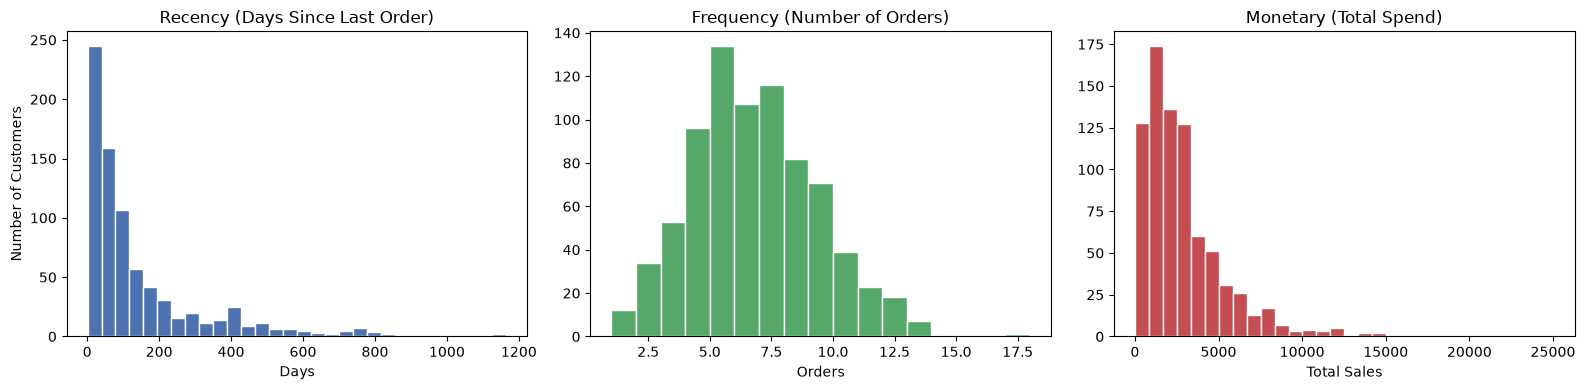

In [108]:
# 1) Distribution histograms of the three raw metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(rfm["Recency"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Recency (Days Since Last Order)")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Number of Customers")

axes[1].hist(rfm["Frequency"], bins=range(1, rfm["Frequency"].max() + 2), color="#55A868", edgecolor="white")
axes[1].set_title("Frequency (Number of Orders)")
axes[1].set_xlabel("Orders")

axes[2].hist(rfm["Monetary"], bins=30, color="#C44E52", edgecolor="white")
axes[2].set_title("Monetary (Total Spend)")
axes[2].set_xlabel("Total Sales")

plt.tight_layout()
plt.show()

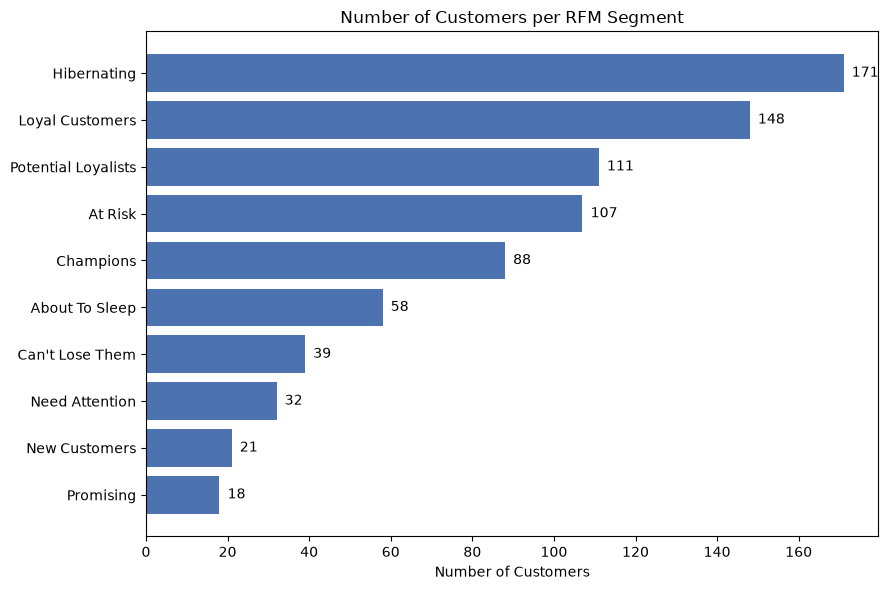

In [109]:
# 2) How many customers land in each segment?
seg_counts = rfm["Segment"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(seg_counts.index.astype(str), seg_counts.values, color="#4C72B0")
plt.title("Number of Customers per RFM Segment")
plt.xlabel("Number of Customers")
for i, v in enumerate(seg_counts.values):
    plt.text(v + 2, i, str(v), va="center")
plt.tight_layout()
plt.show()

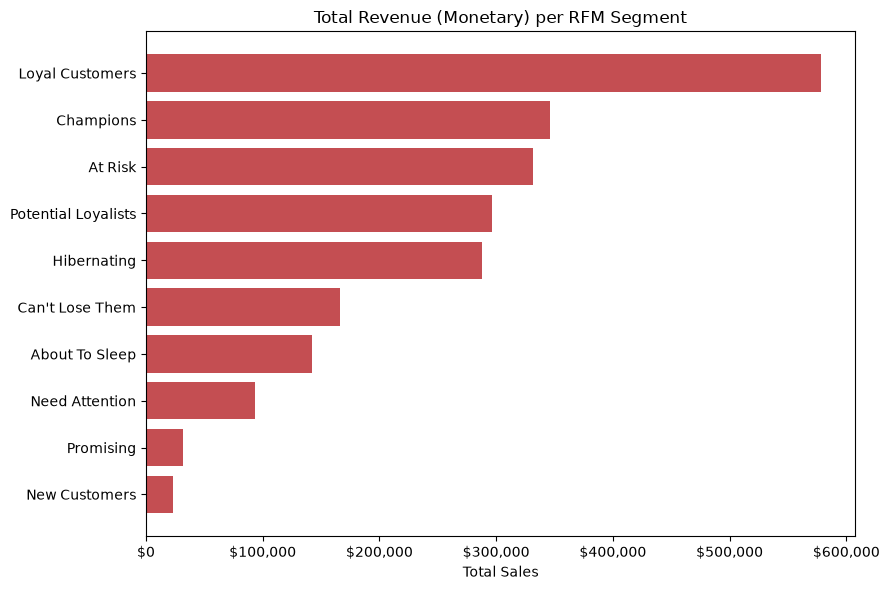

In [110]:
# 3) Revenue contribution per segment (count isn't the whole story)
rev_by_seg = segment_summary["Total_Monetary"].sort_values(ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(rev_by_seg.index.astype(str), rev_by_seg.values, color="#C44E52")
plt.title("Total Revenue (Monetary) per RFM Segment")
plt.xlabel("Total Sales")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

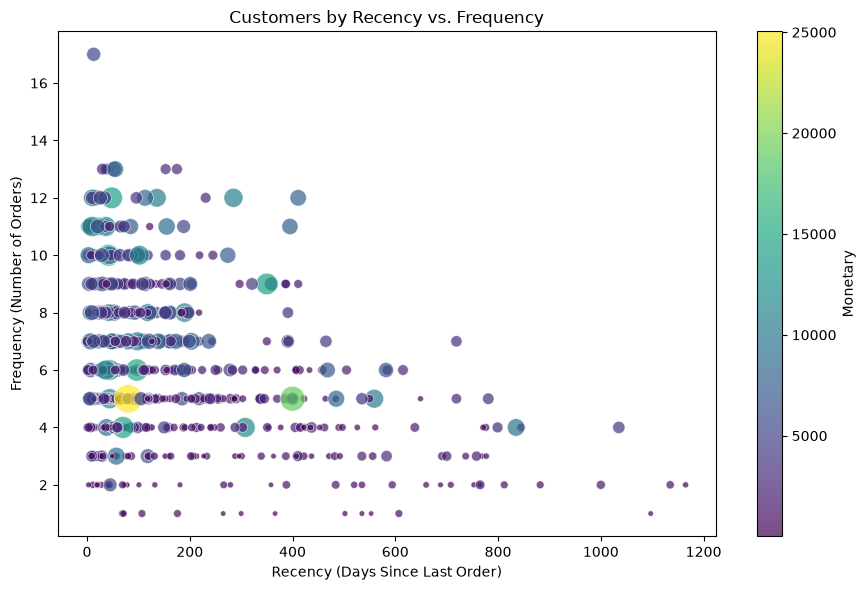

In [111]:
# 4) Scatter plot: Recency vs Frequency, bubble size/color = Monetary
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    rfm["Recency"], rfm["Frequency"],
    s=rfm["Monetary"] / rfm["Monetary"].max() * 400 + 15,  # scale bubble size
    c=rfm["Monetary"], cmap="viridis", alpha=0.7, edgecolors="white", linewidths=0.5,
)
plt.title("Customers by Recency vs. Frequency") # bubble size/color = Monetary
plt.xlabel("Recency (Days Since Last Order)") # lower is better
plt.ylabel("Frequency (Number of Orders)")
cbar = plt.colorbar(scatter)
cbar.set_label("Monetary")
plt.tight_layout()
plt.show()

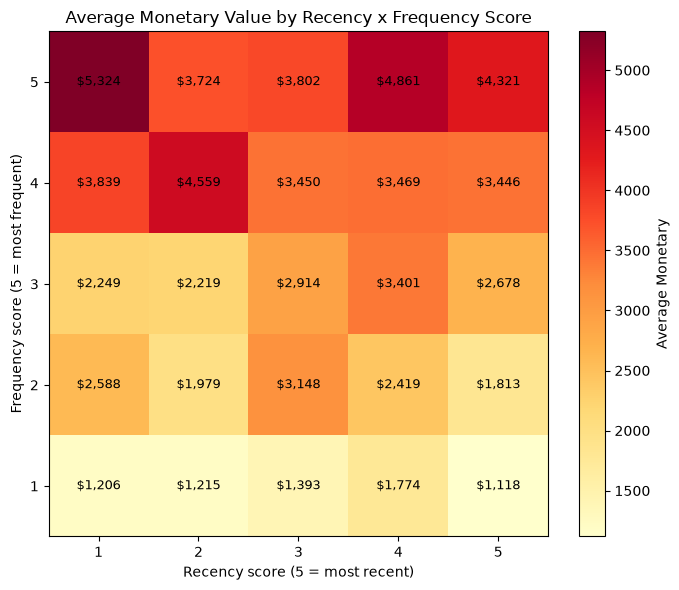

In [113]:
# 5) The classic RFM heatmap: R score x F score, colored by average Monetary
heatmap_data = rfm.pivot_table(
    index="F_Score", columns="R_Score", values="Monetary", aggfunc="mean"
).sort_index(ascending=False)  # highest Frequency score at the top

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(heatmap_data.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xlabel("Recency score (5 = most recent)")
ax.set_ylabel("Frequency score (5 = most frequent)")
ax.set_title("Average Monetary Value by Recency x Frequency Score")

# annotate each cell with its value
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.values[i, j]
        if not np.isnan(value):
            ax.text(j, i, f"${value:,.0f}", ha="center", va="center",
                     color="black", fontsize=9)

fig.colorbar(im, ax=ax, label="Average Monetary")
plt.tight_layout()
plt.show()

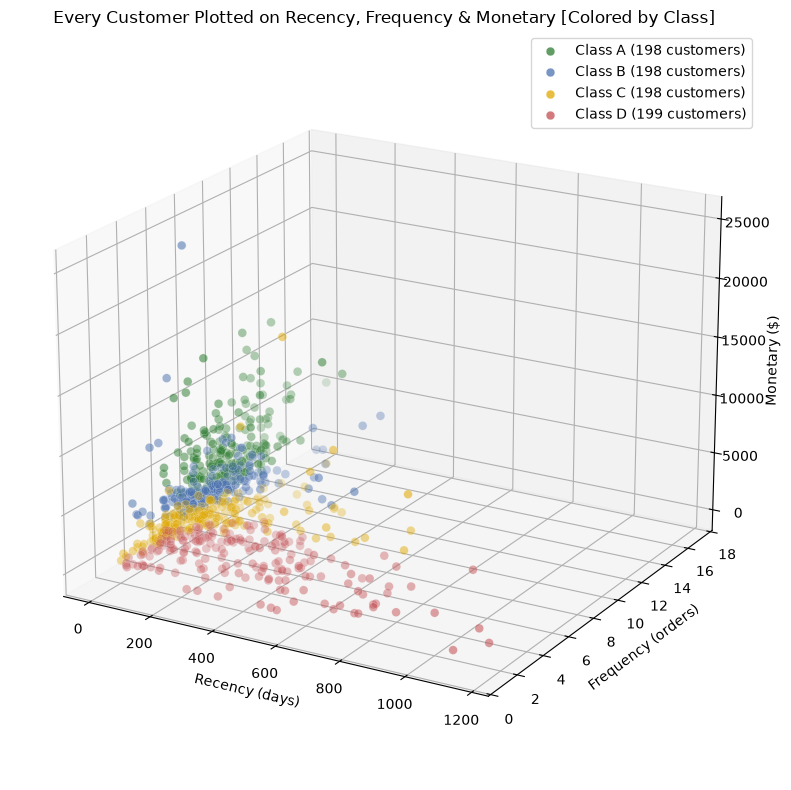

In [114]:
# 6) Customers & RFM together: every customer plotted on all three RFM axes at once, colored by their Class A/B/C/D grade (the combined "customers + RFM" view).
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the '3d' projection)

class_colors = {"A": "#2E7D32", "B": "#4C72B0", "C": "#E0A800", "D": "#C44E52"}

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for cls in ["A", "B", "C", "D"]:
    subset = rfm[rfm["Class"] == cls]
    ax.scatter(
        subset["Recency"], subset["Frequency"], subset["Monetary"],
        s=40, alpha=0.75, color=class_colors[cls], edgecolors="white", linewidths=0.3,
        label=f"Class {cls} ({len(subset)} customers)",
    )

ax.set_xlabel("Recency (days)")
ax.set_ylabel("Frequency (orders)")
ax.set_zlabel("Monetary ($)")
ax.set_title("Every Customer Plotted on Recency, Frequency & Monetary [Colored by Class]")
ax.legend(loc="upper right")
ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.show()

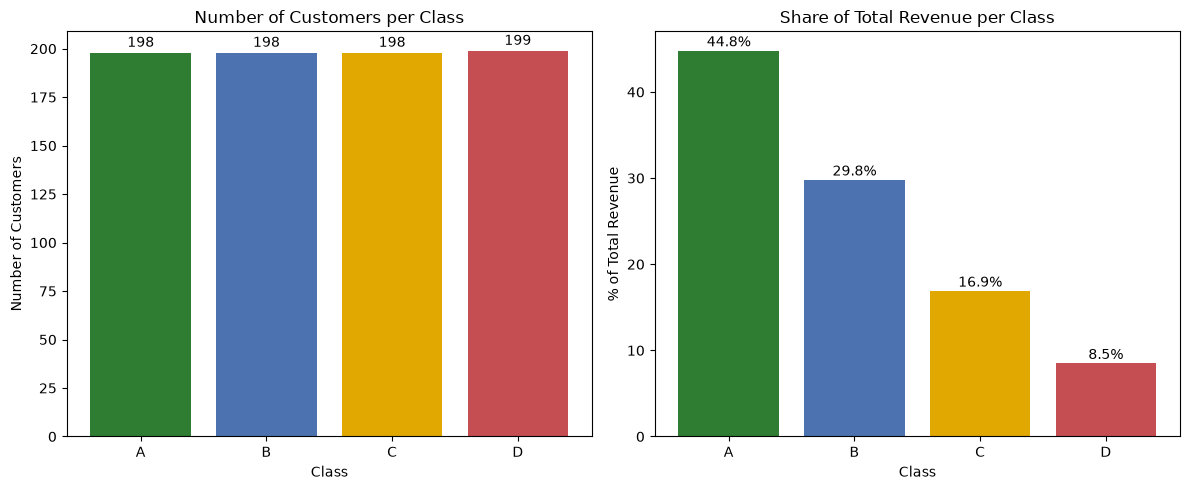

In [115]:
# 7) Class A/B/C/D: customer count vs. revenue share, side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
class_order = ["A", "B", "C", "D"]
colors = [class_colors[c] for c in class_order]

axes[0].bar(class_order, class_summary.loc[class_order, "Customers"], color=colors)
axes[0].set_title("Number of Customers per Class")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Customers")
for i, v in enumerate(class_summary.loc[class_order, "Customers"]):
    axes[0].text(i, v + 3, str(v), ha="center")

axes[1].bar(class_order, class_summary.loc[class_order, "Pct_of_Revenue"], color=colors)
axes[1].set_title("Share of Total Revenue per Class")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("% of Total Revenue")
for i, v in enumerate(class_summary.loc[class_order, "Pct_of_Revenue"]):
    axes[1].text(i, v + 0.5, f"{v}%", ha="center")

plt.tight_layout()
plt.show()

**What I did:**

1. Cleaned the raw order-level Superstore export (missing `Postal Code`, casing/whitespace consistency, correct `datetime` types, verified no duplicates, sanity-checked `Sales` outliers).
2. Rolled 9,994 order lines up into **793 customers**, each with a Recency, Frequency, and Monetary value computed from a fixed snapshot date.
3. Scored every customer 1-5 on each dimension using **quantile (quintile) binning**: the standard, distribution-agnostic way to make Recency/Frequency/Monetary comparable despite their very different scales and skew.
4. Ranked the full customer list by combined RFM score (ties broken by Monetary) and mapped R+F score combinations onto **10 named, actionable segments**.
5. Simplified that into a single **Class A / B / C / D** letter grade per customer, using the same quantile logic on the combined `RFM_Score` (an easy-to-report tier on top of the richer segment labels).
6. Visualized the results with seven chart types covering both the aggregate and the individual-customer view: distribution histograms, segment count/revenue bar charts, an R-vs-F bubble scatter, the classic RFM heatmap, a **3D customer-level scatter** plotting every customer on Recency/Frequency/Monetary at once (colored by Class), and Class count/revenue bar charts.